In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/DSC 478 Project/household_power_consumption.txt', sep = ';', na_values=['?'])

In [ ]:
data.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [ ]:
data.sample(5)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1942619,26/8/2010,18:23:00,1.316,0.000,241.44,5.4,0.0,0.0,18.0
1196043,26/3/2009,07:27:00,1.938,0.088,244.32,7.8,0.0,0.0,18.0
1914788,7/8/2010,10:32:00,0.230,0.086,238.89,1.0,0.0,0.0,0.0
1019649,23/11/2008,19:33:00,3.032,0.150,238.25,12.6,0.0,0.0,17.0
344887,13/8/2007,05:31:00,0.138,0.000,234.40,0.6,0.0,1.0,0.0


In [ ]:
data.shape

(2075259, 9)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


In [ ]:
data.isnull().sum()

,0
Date,0
Time,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data['Date'] = pd.to_datetime(data['Date'], format='%d/%m/%Y')

In [ ]:
data['Time'] = pd.to_datetime(data['Time'], format='%H:%M:%S').dt.time

In [ ]:
data['DateTime'] = pd.to_datetime(data['Date'].astype(str) + ' ' + data['Time'].astype(str))

In [ ]:
data['DateTime'].head(5)

,DateTime
0,2006-12-16 17:24:00
1,2006-12-16 17:25:00
2,2006-12-16 17:26:00
3,2006-12-16 17:27:00
4,2006-12-16 17:28:00


In [ ]:
numeric_col = ['Global_active_power', 'Global_reactive_power', 'Voltage','Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3']

for col in numeric_col:
  data[col] = pd.to_numeric(data[col], errors='coerce')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 10 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   datetime64[ns]
 1   Time                   object        
 2   Global_active_power    float64       
 3   Global_reactive_power  float64       
 4   Voltage                float64       
 5   Global_intensity       float64       
 6   Sub_metering_1         float64       
 7   Sub_metering_2         float64       
 8   Sub_metering_3         float64       
 9   DateTime               datetime64[ns]
dtypes: datetime64[ns](2), float64(7), object(1)
memory usage: 158.3+ MB


In [ ]:
data.describe()

,Date,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DateTime
count,2075259,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2075259
mean,2008-12-05 19:13:27.255191040,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00,2008-12-06 07:12:59.999994112
min,2006-12-16 00:00:00,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,2006-12-16 17:24:00
25%,2007-12-12 00:00:00,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2007-12-12 00:18:30
50%,2008-12-06 00:00:00,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2008-12-06 07:13:00
75%,2009-12-01 00:00:00,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01,2009-12-01 14:07:30
max,2010-11-26 00:00:00,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01,2010-11-26 21:02:00
std,NaN,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00,NaN


**Missing Values: Forward Fill (Data is Time-Series )**

In [ ]:
data.fillna(method='ffill', inplace=True)

/tmp/ipython-input-389/2866031220.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


In [ ]:
data.isnull().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0
DateTime,0


**Creating Features from DateTime**

In [ ]:
data['Hour'] = data['DateTime'].dt.hour          # 0-23
data['DayOfWeek'] = data['DateTime'].dt.dayofweek  # 0=Monday, 6=Sunday
data['Day'] = data['DateTime'].dt.day            # 1-31
data['Month'] = data['DateTime'].dt.month        # 1-12
data['Year'] = data['DateTime'].dt.year          # e.g., 2026
data['DayOfYear'] = data['DateTime'].dt.dayofyear  # 1-365
data['WeekOfYear'] = data['DateTime'].dt.isocalendar().week  # 1-52
data['Quarter'] = data['DateTime'].dt.quarter    # 1-4
data['IsWeekend'] = data['DayOfWeek'].isin([5, 6]).astype(int)

In [ ]:
data.sample(5)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DateTime,Hour,DayOfWeek,Day,Month,Year,DayOfYear,WeekOfYear,Quarter,IsWeekend
1396164,2009-08-12,06:48:00,0.312,0.246,240.73,1.6,0.0,2.0,0.0,2009-08-12 06:48:00,6,2,12,8,2009,224,33,3,0
1494297,2009-10-19,10:21:00,1.306,0.048,242.02,5.4,0.0,0.0,19.0,2009-10-19 10:21:00,10,0,19,10,2009,292,43,4,0
1345543,2009-07-08,03:07:00,0.370,0.236,241.75,1.8,0.0,1.0,1.0,2009-07-08 03:07:00,3,2,8,7,2009,189,28,3,0
1775750,2010-05-02,21:14:00,3.604,0.186,235.12,15.4,1.0,17.0,18.0,2010-05-02 21:14:00,21,6,2,5,2010,122,17,2,1
1738917,2010-04-07,07:21:00,2.620,0.000,240.97,10.8,0.0,0.0,19.0,2010-04-07 07:21:00,7,2,7,4,2010,97,14,2,0


**Converting a continuous number into a YES/NO classification problem**

In [ ]:
median_power = data['Global_active_power'].median()

In [ ]:
median_power

0.598

In [ ]:
data['high_usage'] = (data['Global_active_power'] > median_power).astype(int)

In [ ]:
data[['Global_active_power','high_usage']].sample(5)

,Global_active_power,high_usage
627452,0.314,0
742799,0.226,0
1019238,4.942,1
499298,1.354,1
1068354,1.430,1


In [ ]:
data.shape

(2075259, 20)

**EDA**

In [ ]:
data_sample = data.sample(n=500000, random_state=42)

In [ ]:
data_sample = data_sample.sort_values('DateTime').reset_index(drop=True)

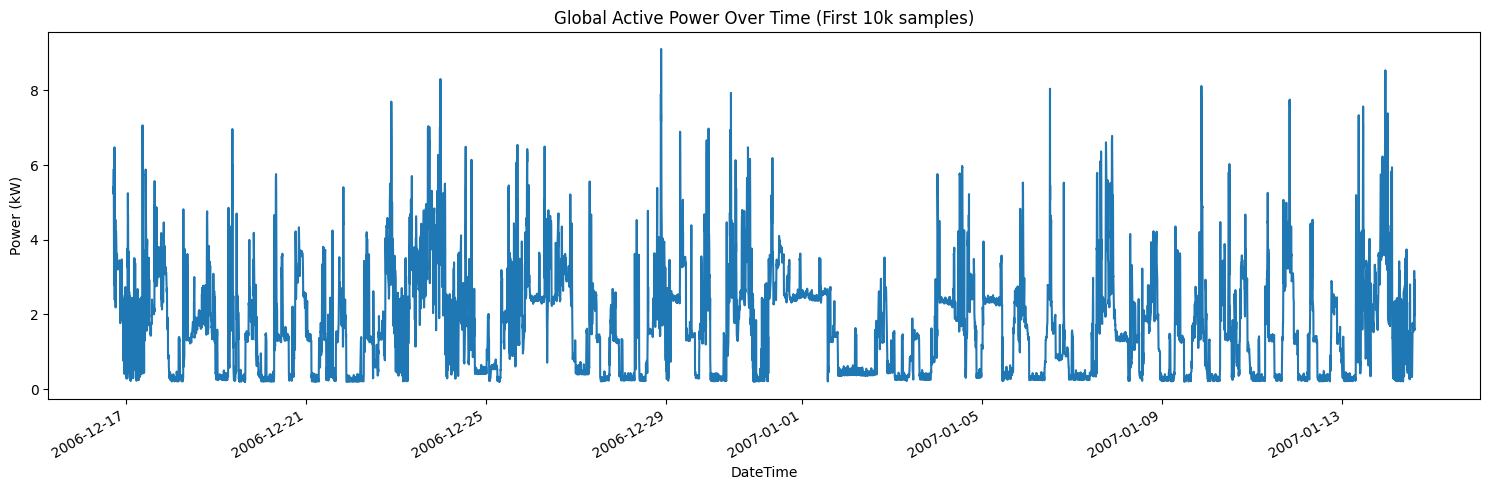

In [ ]:
# Time series plot
plt.figure(figsize=(15, 5))
data_sample.set_index('DateTime')['Global_active_power'][:10000].plot()
plt.title('Global Active Power Over Time (First 10k samples)')
plt.ylabel('Power (kW)')
plt.xlabel('DateTime')
plt.tight_layout()
plt.show()

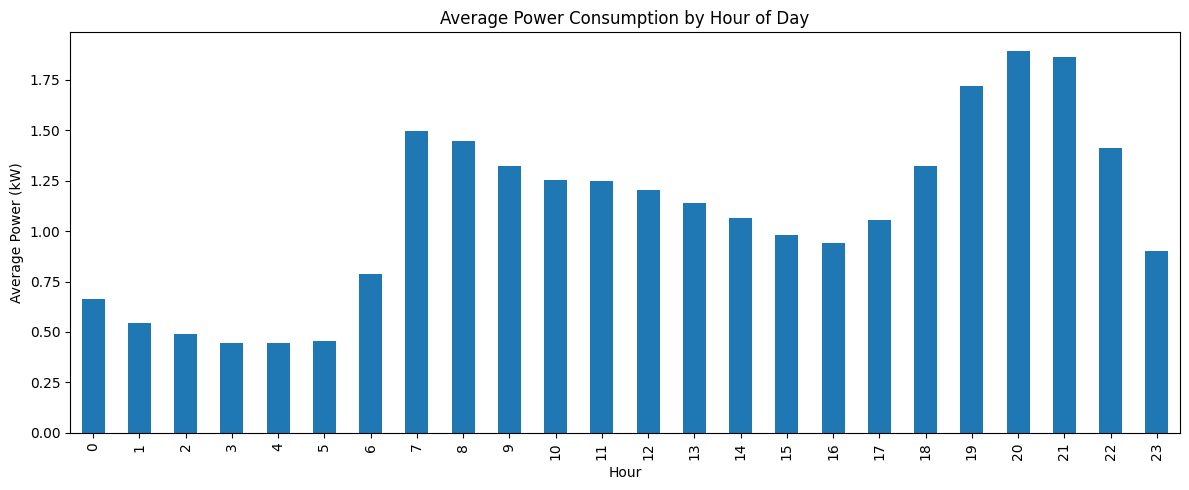

In [ ]:
# Daily pattern
plt.figure(figsize=(12, 5))
data_sample.groupby('Hour')['Global_active_power'].mean().plot(kind='bar')
plt.title('Average Power Consumption by Hour of Day')
plt.ylabel('Average Power (kW)')
plt.xlabel('Hour')
plt.tight_layout()
plt.show()

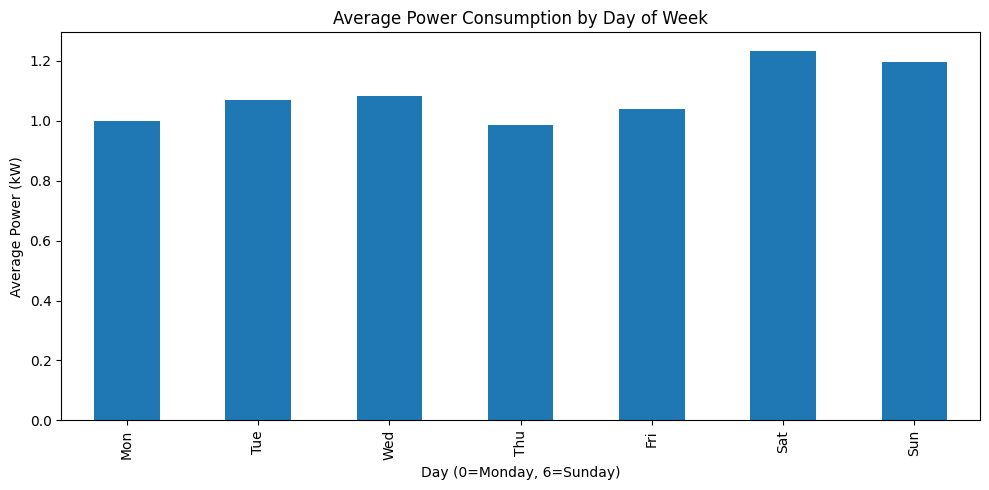

In [ ]:
# Weekly pattern
plt.figure(figsize=(10, 5))
data_sample.groupby('DayOfWeek')['Global_active_power'].mean().plot(kind='bar')
plt.title('Average Power Consumption by Day of Week')
plt.ylabel('Average Power (kW)')
plt.xlabel('Day (0=Monday, 6=Sunday)')
plt.xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.tight_layout()
plt.show()

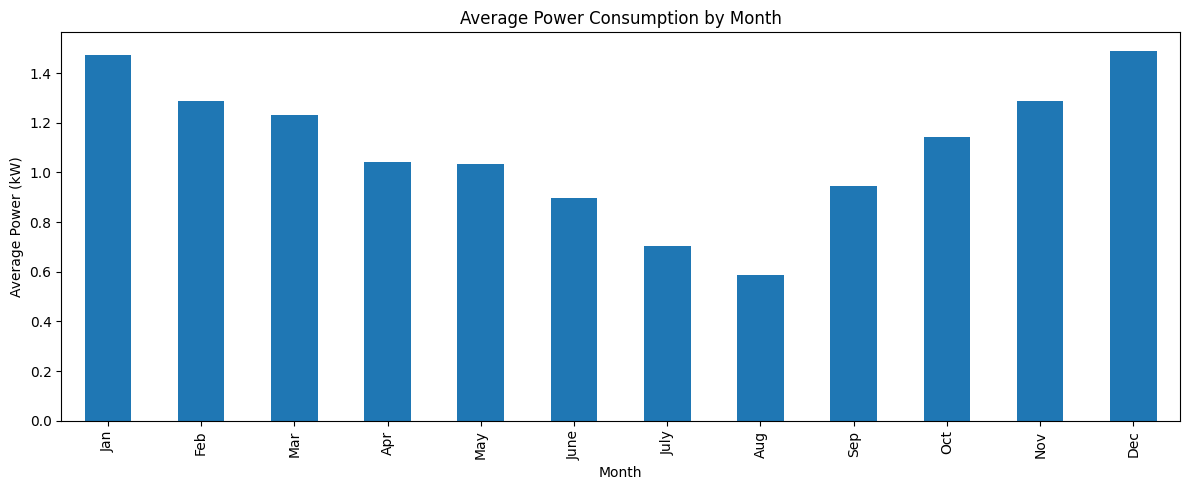

In [ ]:
# Monthly pattern
plt.figure(figsize=(12, 5))
data_sample.groupby('Month')['Global_active_power'].mean().plot(kind='bar')
plt.title('Average Power Consumption by Month')
plt.ylabel('Average Power (kW)')
plt.xlabel('Month')
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'July','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

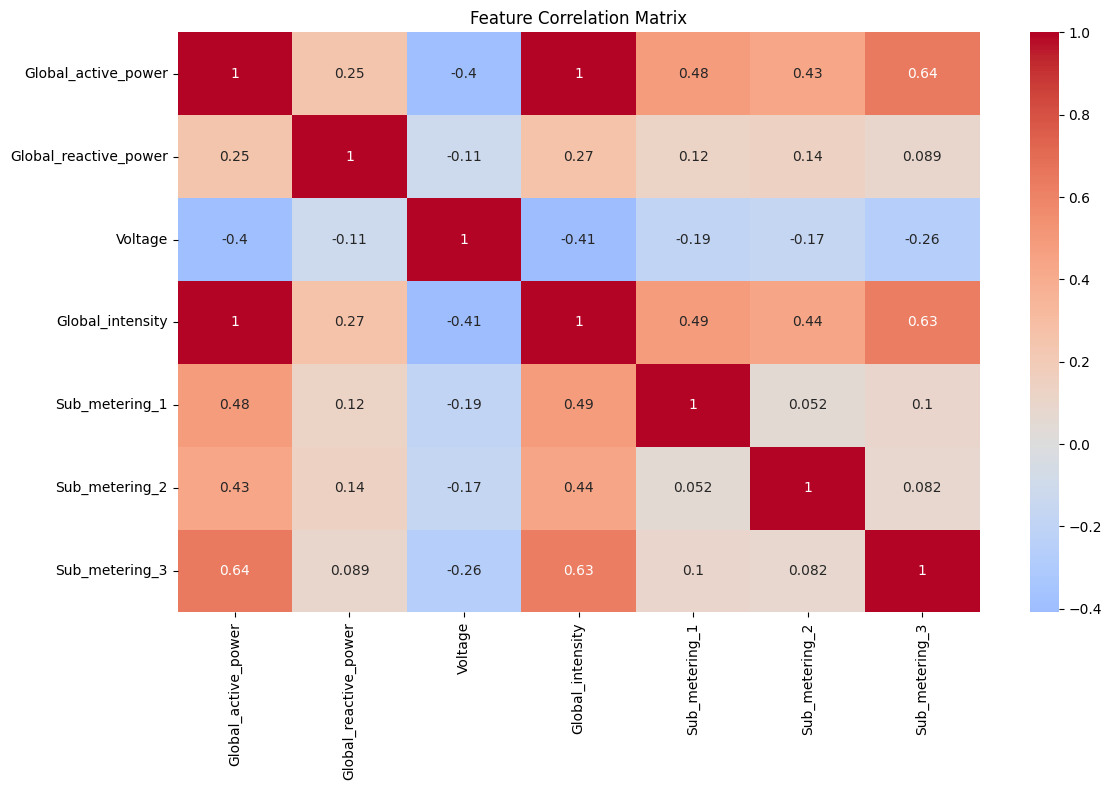

In [ ]:
# Feature correlations
plt.figure(figsize=(12, 8))
corr_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage',
             'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
sns.heatmap(data_sample[corr_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

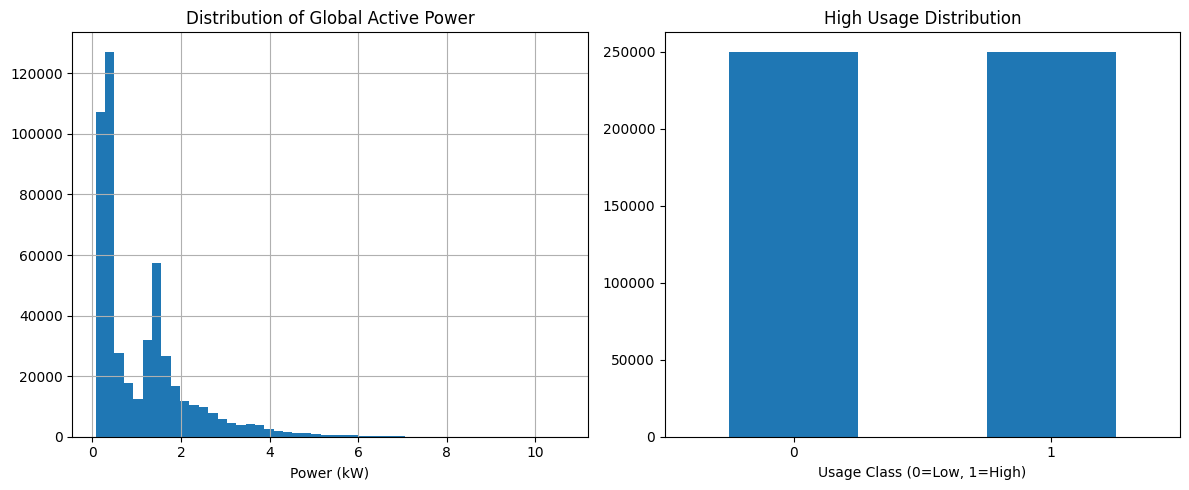

In [ ]:
# Distribution of target
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
data_sample['Global_active_power'].hist(bins=50)
plt.title('Distribution of Global Active Power')
plt.xlabel('Power (kW)')

plt.subplot(1, 2, 2)
data_sample['high_usage'].value_counts().plot(kind='bar')
plt.title('High Usage Distribution')
plt.xlabel('Usage Class (0=Low, 1=High)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Preparing Data For Model**

Removing Global_intensity as Global_active_power directly calculate from it and it will leads to data leakage.

In [ ]:
data_sample.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'DateTime', 'Hour', 'DayOfWeek', 'Day', 'Month',
       'Year', 'DayOfYear', 'WeekOfYear', 'Quarter', 'IsWeekend',
       'high_usage'],
      dtype='object')

In [ ]:
feature_columns = ['Global_reactive_power','Voltage', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'Hour', 'DayOfWeek', 'Day', 'Month',
       'Year', 'DayOfYear', 'WeekOfYear', 'Quarter', 'IsWeekend']

In [ ]:
X = data_sample[feature_columns]
y_regression = data_sample['Global_active_power']
y_classification = data_sample['high_usage']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_regression_train, y_regression_test = train_test_split(X, y_regression, test_size=0.2, random_state=42)

In [ ]:
_, _, y_clf_train, y_clf_test = train_test_split(X, y_classification, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(400000, 14)

In [ ]:
X_test.shape

(100000, 14)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# Feature scaling (important for KMeans)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**Linear Regression for Power Prediction**

In [ ]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, f1_score, roc_auc_score, classification_report, confusion_matrix

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_regression_train)

LinearRegression()

In [ ]:
y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)

In [ ]:
train_rmse = np.sqrt(mean_squared_error(y_regression_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_regression_test, y_pred_test))
train_r2 = r2_score(y_regression_train, y_pred_train)
test_r2 = r2_score(y_regression_test, y_pred_test)

In [ ]:
print(f"\nTrain RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")


Train RMSE: 0.5126
Test RMSE: 0.5097
Train R²: 0.7635
Test R²: 0.7632


In [ ]:
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print("\nTop 5 Most Important Features:")
print(feature_importance.head())


Top 5 Most Important Features:
                  Feature  Coefficient
8                   Month    -3.743661
0   Global_reactive_power     0.805929
10              DayOfYear     0.123349
7                     Day    -0.122594
4          Sub_metering_3     0.065219


**Logistic Regression Classification**

In [ ]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_clf_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# Predictions
y_clf_pred_train = log_model.predict(X_train_scaled)
y_clf_pred_test = log_model.predict(X_test_scaled)
y_clf_proba_test = log_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# Evaluate
train_f1 = f1_score(y_clf_train, y_clf_pred_train)
test_f1 = f1_score(y_clf_test, y_clf_pred_test)
test_auc = roc_auc_score(y_clf_test, y_clf_proba_test)

In [ ]:
print(f"\nTrain F1-Score: {train_f1:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")
print(f"Test AUC: {test_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_clf_test, y_clf_pred_test,
                          target_names=['Low Usage', 'High Usage']))


Train F1-Score: 0.8705
Test F1-Score: 0.8667
Test AUC: 0.9360

Classification Report:
              precision    recall  f1-score   support

   Low Usage       0.82      0.97      0.89     50345
  High Usage       0.96      0.79      0.87     49655

    accuracy                           0.88    100000
   macro avg       0.89      0.88      0.88    100000
weighted avg       0.89      0.88      0.88    100000



In [ ]:
confusion_matrix(y_clf_test,y_clf_pred_test)

array([[48612,  1733],
       [10358, 39297]])

**Random Forest (Regression + Classification)**

In [ ]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier, VotingClassifier

# Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=20,
                               random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_regression_train)

y_rf_pred_test = rf_reg.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_regression_test, y_rf_pred_test))
rf_r2 = r2_score(y_regression_test, y_rf_pred_test)

print(f"Test RMSE: {rf_rmse:.4f}")
print(f"Test R²: {rf_r2:.4f}")

Test RMSE: 0.2900
Test R²: 0.9234


In [ ]:
# Feature importance
rf_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 5 Most Important Features:")
print(rf_importance.head())


Top 5 Most Important Features:
          Feature  Importance
4  Sub_metering_3    0.441485
2  Sub_metering_1    0.178314
3  Sub_metering_2    0.136311
5            Hour    0.068341
1         Voltage    0.044634


<Figure size 1000x600 with 0 Axes>

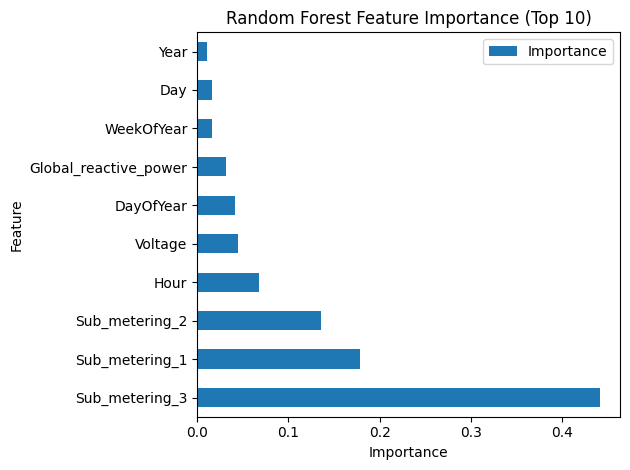

In [ ]:
# Plot feature importance
plt.figure(figsize=(10, 6))
rf_importance.head(10).plot(x='Feature', y='Importance', kind='barh')
plt.title('Random Forest Feature Importance (Top 10)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
# Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=20,
                                random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_clf_train)

y_rf_clf_pred = rf_clf.predict(X_test)
y_rf_clf_proba = rf_clf.predict_proba(X_test)[:, 1]

rf_f1 = f1_score(y_clf_test, y_rf_clf_pred)
rf_auc = roc_auc_score(y_clf_test, y_rf_clf_proba)

print(f"Test F1-Score: {rf_f1:.4f}")
print(f"Test AUC: {rf_auc:.4f}")

Test F1-Score: 0.9586
Test AUC: 0.9938


**K-Means Clustering**

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, f1_score, roc_auc_score, silhouette_score, classification_report

# Use scaled features for clustering
clustering_features = ['Global_active_power', 'Hour', 'DayOfWeek',
                       'Global_intensity', 'Voltage']
X_cluster = data_sample[clustering_features]
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)

# Train K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)

# Add clusters to data
data_sample['Cluster'] = clusters

# Evaluate
silhouette = silhouette_score(X_cluster_scaled, clusters, sample_size=50000)
print(f"\nSilhouette Score: {silhouette:.4f}")

# Analyze clusters
print("\nCluster Statistics:")
cluster_stats = data_sample.groupby('Cluster').agg({
    'Global_active_power': ['mean', 'std', 'count'],
    'Hour': 'mean',
    'DayOfWeek': 'mean',
    'Global_intensity': 'mean'
}).round(2)
print(cluster_stats)


Silhouette Score: 0.2303

Cluster Statistics:
        Global_active_power                 Hour DayOfWeek Global_intensity
                       mean   std   count   mean      mean             mean
Cluster                                                                    
0                      0.97  0.61  156990  14.92      4.51             4.08
1                      0.42  0.35  147792   3.56      3.11             1.82
2                      3.25  1.01   62373  15.37      3.35            13.74
3                      0.96  0.63  132845  14.50      0.93             4.04


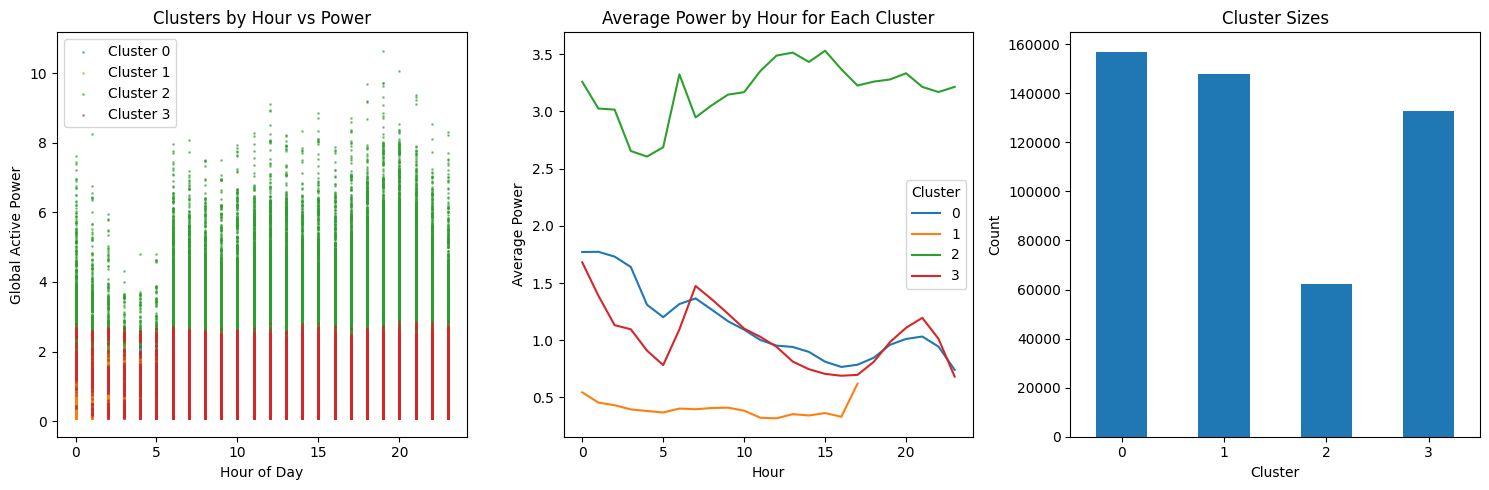

In [ ]:
# Visualize clusters
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
for cluster in range(4):
    cluster_data = data_sample[data_sample['Cluster'] == cluster]
    plt.scatter(cluster_data['Hour'], cluster_data['Global_active_power'],
                label=f'Cluster {cluster}', alpha=0.5, s=1)
plt.xlabel('Hour of Day')
plt.ylabel('Global Active Power')
plt.title('Clusters by Hour vs Power')
plt.legend()

plt.subplot(1, 3, 2)
data_sample.groupby(['Cluster', 'Hour'])['Global_active_power'].mean().unstack(0).plot(ax=plt.gca())
plt.title('Average Power by Hour for Each Cluster')
plt.xlabel('Hour')
plt.ylabel('Average Power')
plt.legend(title='Cluster')

plt.subplot(1, 3, 3)
data_sample['Cluster'].value_counts().sort_index().plot(kind='bar')
plt.title('Cluster Sizes')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Interpret clusters
print("\nCluster Interpretation:")
for cluster in range(4):
    cluster_data = data_sample[data_sample['Cluster'] == cluster]
    avg_hour = cluster_data['Hour'].mean()
    avg_power = cluster_data['Global_active_power'].mean()
    print(f"\nCluster {cluster}:")
    print(f"  Average Hour: {avg_hour:.1f}")
    print(f"  Average Power: {avg_power:.2f} kW")

    if avg_hour < 6:
        print("  Likely: Nighttime/Early Morning usage")
    elif 6 <= avg_hour < 12:
        print("  Likely: Morning usage")
    elif 12 <= avg_hour < 18:
        print("  Likely: Afternoon usage")
    else:
        print("  Likely: Evening/Peak usage")


Cluster Interpretation:

Cluster 0:
  Average Hour: 14.9
  Average Power: 0.97 kW
  Likely: Afternoon usage

Cluster 1:
  Average Hour: 3.6
  Average Power: 0.42 kW
  Likely: Nighttime/Early Morning usage

Cluster 2:
  Average Hour: 15.4
  Average Power: 3.25 kW
  Likely: Afternoon usage

Cluster 3:
  Average Hour: 14.5
  Average Power: 0.96 kW
  Likely: Afternoon usage


**Voting Ensemble (Classification)**

In [ ]:
# Define base models
estimators = [
    ('logistic', LogisticRegression(max_iter=1000, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42))
]

# Create voting classifier (soft voting for probabilities)
voting_clf = VotingClassifier(estimators=estimators, voting='soft')
voting_clf.fit(X_train_scaled, y_clf_train)

# Predictions
y_voting_pred = voting_clf.predict(X_test_scaled)
y_voting_proba = voting_clf.predict_proba(X_test_scaled)[:, 1]

# Evaluate
voting_f1 = f1_score(y_clf_test, y_voting_pred)
voting_auc = roc_auc_score(y_clf_test, y_voting_proba)

print(f"\nVoting Ensemble F1-Score: {voting_f1:.4f}")
print(f"Voting Ensemble AUC: {voting_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_clf_test, y_voting_pred,
                          target_names=['Low Usage', 'High Usage']))


Voting Ensemble F1-Score: 0.9287
Voting Ensemble AUC: 0.9858

Classification Report:
              precision    recall  f1-score   support

   Low Usage       0.89      0.98      0.94     50345
  High Usage       0.98      0.88      0.93     49655

    accuracy                           0.93    100000
   macro avg       0.94      0.93      0.93    100000
weighted avg       0.94      0.93      0.93    100000



**Compare All Models**


--- REGRESSION MODELS ---
                  Model     RMSE       R²
      Linear Regression 0.509705 0.763233
Random Forest Regressor 0.289984 0.923364

--- CLASSIFICATION MODELS ---
                   Model  F1-Score      AUC
     Logistic Regression  0.866670 0.936040
Random Forest Classifier  0.958611 0.993837
         Voting Ensemble  0.928666 0.985764

--- CLUSTERING ---
K-Means Silhouette Score: 0.2303


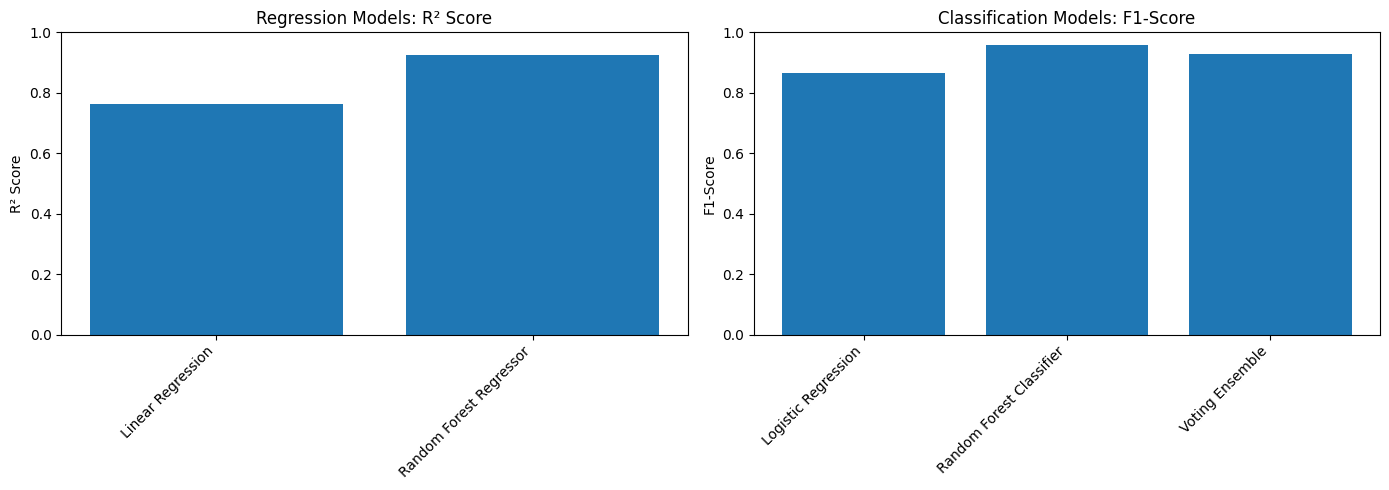

In [ ]:
# Regression models comparison
regression_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'RMSE': [test_rmse, rf_rmse],
    'R²': [test_r2, rf_r2]
})

print("\n--- REGRESSION MODELS ---")
print(regression_results.to_string(index=False))

# Classification models comparison
classification_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest Classifier', 'Voting Ensemble'],
    'F1-Score': [test_f1, rf_f1, voting_f1],
    'AUC': [test_auc, rf_auc, voting_auc]
})

print("\n--- CLASSIFICATION MODELS ---")
print(classification_results.to_string(index=False))

print(f"\n--- CLUSTERING ---")
print(f"K-Means Silhouette Score: {silhouette:.4f}")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regression comparison
axes[0].bar(regression_results['Model'], regression_results['R²'])
axes[0].set_title('Regression Models: R² Score')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Classification comparison
axes[1].bar(classification_results['Model'], classification_results['F1-Score'])
axes[1].set_title('Classification Models: F1-Score')
axes[1].set_ylabel('F1-Score')
axes[1].set_ylim(0, 1)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()